Le notebook **03_analyse_exploratoire_scores_profils.ipynb** est utile parce que le scoring donne seulement les **notes**, mais l’analyse exploratoire explique **ce que ces notes signifient**.

Après `02_scoring_pedagogique_niveaux.ipynb`, on a :

```text
scores + niveaux + progression
```

Mais il faut encore comprendre :

```text
- qui sont les apprenants Débutant / Intermédiaire / Avancé ;
- quels parcours réussissent mieux : DA, BI, DS, IA ;
- où les apprenants progressent le plus ;
- quels profils ont plus de difficulté ;
- s’il y a des anomalies dans les scores ;
- quelles variables semblent importantes avant le ML.
```

Donc :

```text
Étape 2 = calculer les notes.
Étape 3 = analyser et comprendre les notes.
```

C’est une étape nécessaire avant la modélisation ML.


03_analyse_exploratoire_scores_profils.ipynb:
Objectif : comprendre les scores, niveaux, progressions et profils avant le ML.

On va analyser:
- distribution des scores initiaux ;
- distribution des scores intermédiaires ;
- distribution des scores finaux ;
- niveaux Débutant / Intermédiaire / Avancé ;
- progression initiale → finale ;
- performance par parcours DA, BI, DS, IA ;
- profils des apprenants selon âge, genre, filière, niveau, motivation, disponibilité ;
- premières visualisations.

# Cellule 1 — Imports

In [1]:
# ============================================================
# ÉTAPE 3 — ANALYSE EXPLORATOIRE DES SCORES ET PROFILS
# ============================================================

import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 200)

# Cellule 2 — Chemins des fichiers scorés

In [2]:
# ============================================================
# 3.1. Chemins des fichiers issus de l'Étape 2
# ============================================================

INPUT_DIR = Path("outputs/02_scoring_pedagogique")
OUTPUT_DIR = Path("outputs/03_analyse_exploratoire")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PATH_SCORES_INITIAL = INPUT_DIR / "01_scores_test_initial.csv"
PATH_SCORES_INTERMEDIAIRES = INPUT_DIR / "02_scores_tests_intermediaires.csv"
PATH_SCORES_FINAUX = INPUT_DIR / "03_scores_tests_finaux.csv"

PATH_DATASET_ORIENTATION = INPUT_DIR / "04_dataset_orientation_score.csv"
PATH_DATASET_PREDICTION = INPUT_DIR / "05_dataset_prediction_score.csv"
PATH_DATASET_LONGITUDINAL = INPUT_DIR / "06_dataset_longitudinal_score.csv"

fichiers = {
    "scores_initial": PATH_SCORES_INITIAL,
    "scores_intermediaires": PATH_SCORES_INTERMEDIAIRES,
    "scores_finaux": PATH_SCORES_FINAUX,
    "dataset_orientation_score": PATH_DATASET_ORIENTATION,
    "dataset_prediction_score": PATH_DATASET_PREDICTION,
    "dataset_longitudinal_score": PATH_DATASET_LONGITUDINAL,
}

for nom, chemin in fichiers.items():
    print(f"{nom:35s} | existe = {chemin.exists()} | {chemin}")

scores_initial                      | existe = True | outputs/02_scoring_pedagogique/01_scores_test_initial.csv
scores_intermediaires               | existe = True | outputs/02_scoring_pedagogique/02_scores_tests_intermediaires.csv
scores_finaux                       | existe = True | outputs/02_scoring_pedagogique/03_scores_tests_finaux.csv
dataset_orientation_score           | existe = True | outputs/02_scoring_pedagogique/04_dataset_orientation_score.csv
dataset_prediction_score            | existe = True | outputs/02_scoring_pedagogique/05_dataset_prediction_score.csv
dataset_longitudinal_score          | existe = True | outputs/02_scoring_pedagogique/06_dataset_longitudinal_score.csv


# Cellule 3 — Chargement des données scorées

In [3]:
# ============================================================
# 3.2. Chargement des datasets scorés
# ============================================================

df_scores_initial = pd.read_csv(PATH_SCORES_INITIAL)
df_scores_intermediaires = pd.read_csv(PATH_SCORES_INTERMEDIAIRES)
df_scores_finaux = pd.read_csv(PATH_SCORES_FINAUX)

df_orientation_score = pd.read_csv(PATH_DATASET_ORIENTATION)
df_prediction_score = pd.read_csv(PATH_DATASET_PREDICTION)
df_longitudinal_score = pd.read_csv(PATH_DATASET_LONGITUDINAL)

print("Chargement terminé.")

print("Scores initial :", df_scores_initial.shape)
print("Scores intermédiaires :", df_scores_intermediaires.shape)
print("Scores finaux :", df_scores_finaux.shape)

print("Dataset orientation scoré :", df_orientation_score.shape)
print("Dataset prédiction scoré :", df_prediction_score.shape)
print("Dataset longitudinal scoré :", df_longitudinal_score.shape)

Chargement terminé.
Scores initial : (305, 57)
Scores intermédiaires : (196, 37)
Scores finaux : (206, 37)
Dataset orientation scoré : (305, 59)
Dataset prédiction scoré : (128, 91)
Dataset longitudinal scoré : (125, 119)


# Cellule 4 — Fonctions utiles

In [4]:
# ============================================================
# 3.3. Fonctions utiles pour l'analyse exploratoire
# ============================================================

def afficher_resume_score(df, colonne_score, nom_score):
    print(f"\n===== {nom_score} =====")
    display(df[colonne_score].describe())
    
    print("\nValeurs manquantes :", df[colonne_score].isna().sum())
    print("Minimum :", df[colonne_score].min())
    print("Maximum :", df[colonne_score].max())


def afficher_repartition(df, colonne, titre):
    print(f"\n===== {titre} =====")
    repartition = df[colonne].value_counts(dropna=False)
    display(repartition)
    
    repartition_pct = df[colonne].value_counts(normalize=True, dropna=False) * 100
    display(repartition_pct.round(2))


def exporter_tableau(df, nom_fichier):
    chemin = OUTPUT_DIR / nom_fichier
    df.to_csv(chemin, index=False, encoding="utf-8-sig")
    print("Exporté :", chemin)

# Cellule 5 — Synthèse générale des scores

Score initial faible : moyenne 4,58 /20
Score intermédiaire élevé : moyenne 10,81 /15
Score final élevé : moyenne 11,00 /15

In [5]:
# ============================================================
# 3.4. Synthèse générale des scores
# ============================================================

# Résumé statistique
afficher_resume_score(df_scores_initial, "score_initial_total", "Score initial total /20")
afficher_resume_score(df_scores_intermediaires, "score_intermediaire_total", "Score intermédiaire total /15")
afficher_resume_score(df_scores_finaux, "score_final_total", "Score final total /15")

# Répartition des niveaux
afficher_repartition(df_scores_initial, "niveau_initial_global", "Niveaux initiaux")
afficher_repartition(df_scores_intermediaires, "niveau_intermediaire", "Niveaux intermédiaires")
afficher_repartition(df_scores_finaux, "niveau_final", "Niveaux finaux")


===== Score initial total /20 =====


count    305.000000
mean       4.577049
std        4.412318
min        0.000000
25%        1.000000
50%        4.000000
75%        6.000000
max       20.000000
Name: score_initial_total, dtype: float64


Valeurs manquantes : 0
Minimum : 0
Maximum : 20

===== Score intermédiaire total /15 =====


count    196.000000
mean      10.811224
std        3.232856
min        2.000000
25%        8.000000
50%       11.000000
75%       14.000000
max       15.000000
Name: score_intermediaire_total, dtype: float64


Valeurs manquantes : 0
Minimum : 2
Maximum : 15

===== Score final total /15 =====


...

niveau_intermediaire
Avancé           108
Intermédiaire     54
Débutant          34
Name: count, dtype: int64

niveau_intermediaire
Avancé           55.10
Intermédiaire    27.55
Débutant         17.35
Name: proportion, dtype: float64


===== Niveaux finaux =====


niveau_final
Avancé           126
Débutant          41
Intermédiaire     39
Name: count, dtype: int64

niveau_final
Avancé           61.17
Débutant         19.90
Intermédiaire    18.93
Name: proportion, dtype: float64

Score initial faible : moyenne 4,58 /20
Score intermédiaire élevé : moyenne 10,81 /15
Score final élevé : moyenne 11,00 /15

Donc on voit déjà une forte progression globale.

# Cellule 6 — Graphiques des distributions des scores

In [6]:
# ============================================================
# 3.5. Graphiques des distributions des scores
# ============================================================

FIG_DIR = OUTPUT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

def histogramme_score(df, colonne, titre, xlabel, nom_fichier):
    plt.figure(figsize=(8, 5))
    plt.hist(df[colonne].dropna(), bins=15, edgecolor="black")
    plt.title(titre)
    plt.xlabel(xlabel)
    plt.ylabel("Nombre d'apprenants")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIG_DIR / nom_fichier, dpi=300)
    plt.show()


histogramme_score(
    df_scores_initial,
    "score_initial_total",
    "Distribution du score initial",
    "Score initial /20",
    "distribution_score_initial.png"
)

histogramme_score(
    df_scores_intermediaires,
    "score_intermediaire_total",
    "Distribution du score intermédiaire",
    "Score intermédiaire /15",
    "distribution_score_intermediaire.png"
)

histogramme_score(
    df_scores_finaux,
    "score_final_total",
    "Distribution du score final",
    "Score final /15",
    "distribution_score_final.png"
)

<Figure size 800x500 with 1 Axes>

<Figure size 800x500 with 1 Axes>

<Figure size 800x500 with 1 Axes>

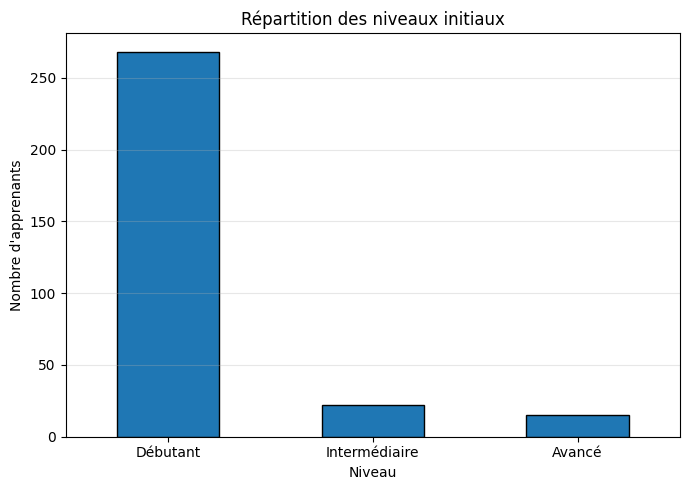

niveau_initial_global
Débutant         268
Intermédiaire     22
Avancé            15
Name: count, dtype: int64

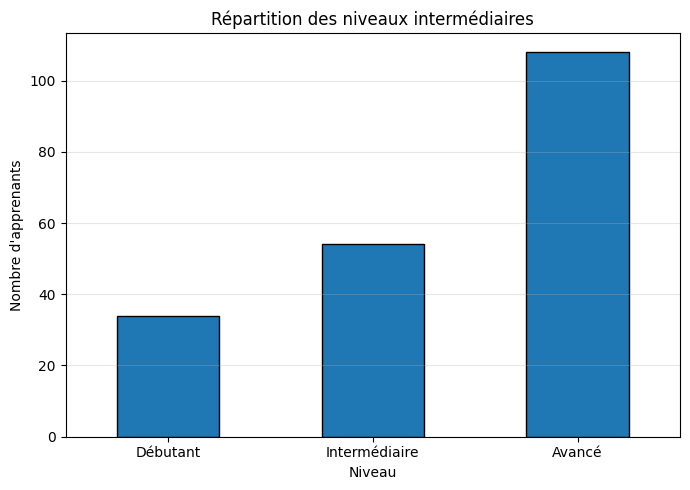

niveau_intermediaire
Débutant          34
Intermédiaire     54
Avancé           108
Name: count, dtype: int64

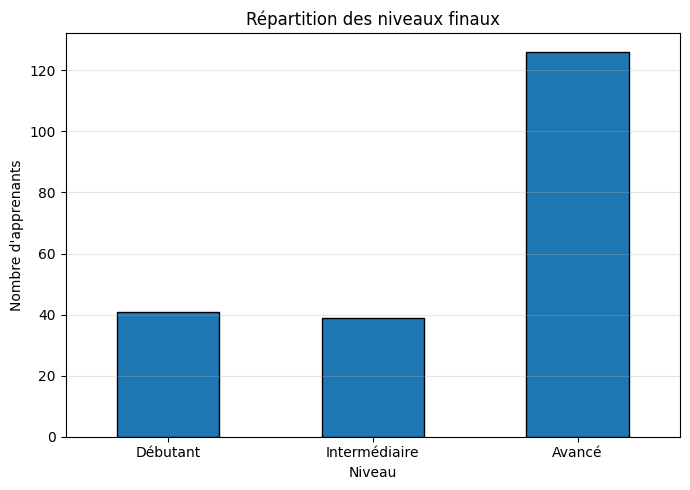

niveau_final
Débutant          41
Intermédiaire     39
Avancé           126
Name: count, dtype: int64

In [7]:
# ============================================================
# 3.5 bis. Graphiques des niveaux Débutant / Intermédiaire / Avancé
# ============================================================

ordre_niveaux = ["Débutant", "Intermédiaire", "Avancé"]

def graphique_niveaux(df, colonne, titre, nom_fichier):
    repartition = df[colonne].value_counts().reindex(ordre_niveaux, fill_value=0)
    
    plt.figure(figsize=(7, 5))
    repartition.plot(kind="bar", edgecolor="black")
    plt.title(titre)
    plt.xlabel("Niveau")
    plt.ylabel("Nombre d'apprenants")
    plt.xticks(rotation=0)
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIG_DIR / nom_fichier, dpi=300)
    plt.show()
    
    display(repartition)


graphique_niveaux(
    df_scores_initial,
    "niveau_initial_global",
    "Répartition des niveaux initiaux",
    "niveaux_initiaux.png"
)

graphique_niveaux(
    df_scores_intermediaires,
    "niveau_intermediaire",
    "Répartition des niveaux intermédiaires",
    "niveaux_intermediaires.png"
)

graphique_niveaux(
    df_scores_finaux,
    "niveau_final",
    "Répartition des niveaux finaux",
    "niveaux_finaux.png"
)

# Cellule 7 — Analyse de la progression initiale → finale

===== Progression initiale → finale =====


count    128.000000
mean      51.484375
std       28.947137
min      -46.666667
25%       34.583333
50%       55.000000
75%       73.333333
max      100.000000
Name: progression_absolue, dtype: float64


Répartition des statuts de progression :


statut_progression
Progression    118
Stable           6
Régression       4
Name: count, dtype: int64


Répartition en pourcentage :


statut_progression
Progression    92.19
Stable          4.69
Régression      3.12
Name: proportion, dtype: float64

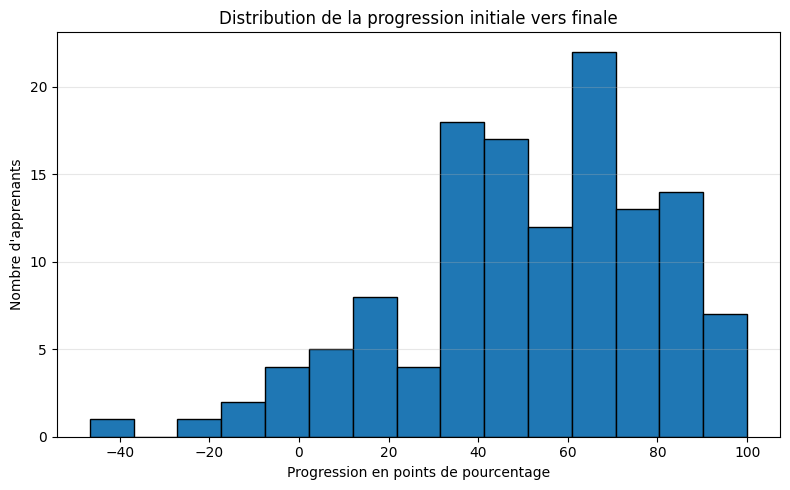

In [8]:
# ============================================================
# 3.6. Analyse de la progression initiale vers finale
# ============================================================

print("===== Progression initiale → finale =====")

display(df_prediction_score["progression_absolue"].describe())

print("\nRépartition des statuts de progression :")
display(df_prediction_score["statut_progression"].value_counts())

print("\nRépartition en pourcentage :")
display(
    (df_prediction_score["statut_progression"].value_counts(normalize=True) * 100).round(2)
)

# Graphique progression
plt.figure(figsize=(8, 5))
plt.hist(df_prediction_score["progression_absolue"].dropna(), bins=15, edgecolor="black")
plt.title("Distribution de la progression initiale vers finale")
plt.xlabel("Progression en points de pourcentage")
plt.ylabel("Nombre d'apprenants")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "distribution_progression_initial_final.png", dpi=300)
plt.show()

Répartition des statuts de progression:

Cela concerne les **128 apprenants** du dataset prédiction scoré.

```text
Progression : 118
```

➡️ 118 apprenants ont amélioré leur score entre le test initial et le test final.

```text
Stable : 6
```

➡️ 6 apprenants ont presque gardé le même niveau.

```text
Régression : 4
```

➡️ 4 apprenants ont eu un score final inférieur au score initial.

Avec notre règle :

```text
Progression : progression_absolue > 5 points
Stable      : entre -5 et +5 points
Régression  : progression_absolue < -5 points
```

Donc conclusion simple :

```text
La majorité des apprenants a progressé après la formation.
```


# Répartition des statuts de progression

===== Progression initiale → finale par parcours =====


,count,mean,std,min,25%,50%,75%,max
parcours_test_final,,,,,,,,
BI,42.0,54.09,27.73,-5.00,33.33,54.17,80.00,100.00
DA,18.0,64.91,26.00,6.67,48.75,70.00,84.17,100.00
DS,28.0,41.61,33.01,-46.67,22.92,44.17,65.42,86.67
IA,40.0,49.62,26.59,-18.33,35.00,54.17,67.08,93.33


,parcours_test_final,nb_apprenants,score_initial_moyen,score_final_moyen,progression_moyenne
0,BI,42,15.60,69.68,54.09
1,DA,18,12.50,77.41,64.91
2,DS,28,34.82,76.43,41.61
3,IA,40,21.88,71.50,49.62


Exporté : outputs/03_analyse_exploratoire/analyse_progression_par_parcours.csv


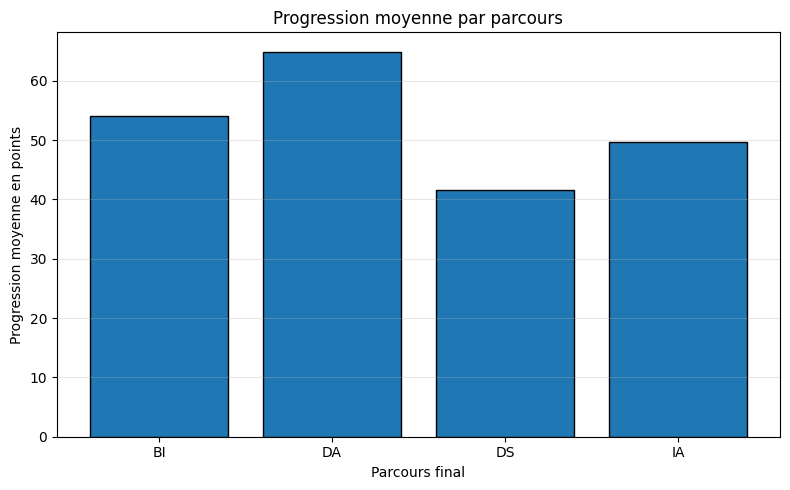

In [9]:
# ============================================================
# 3.7. Analyse de la progression par parcours final
# ============================================================

print("===== Progression initiale → finale par parcours =====")

# Résumé statistique par parcours
resume_progression_parcours = (
    df_prediction_score
    .groupby("parcours_test_final")["progression_absolue"]
    .describe()
    .round(2)
)

display(resume_progression_parcours)

# Moyenne des scores initial/final par parcours
scores_parcours = (
    df_prediction_score
    .groupby("parcours_test_final")
    .agg(
        nb_apprenants=("IDENTIFICATION", "count"),
        score_initial_moyen=("score_initial_pourcentage", "mean"),
        score_final_moyen=("score_final_pourcentage", "mean"),
        progression_moyenne=("progression_absolue", "mean")
    )
    .round(2)
    .reset_index()
)

display(scores_parcours)

# Export
exporter_tableau(
    scores_parcours,
    "analyse_progression_par_parcours.csv"
)

# Graphique progression moyenne par parcours
plt.figure(figsize=(8, 5))
plt.bar(
    scores_parcours["parcours_test_final"],
    scores_parcours["progression_moyenne"],
    edgecolor="black"
)
plt.title("Progression moyenne par parcours")
plt.xlabel("Parcours final")
plt.ylabel("Progression moyenne en points")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "progression_moyenne_par_parcours.png", dpi=300)
plt.show()

Progression moyenne par parcours :
DA : +64,91 points
BI : +54,09 points
IA : +49,62 points
DS : +41,61 points

Donc le parcours DA montre la plus forte progression moyenne.

# Cellule 9 — Transition des niveaux initial → final

Cette cellule va montrer combien d’apprenants sont passés de:
Débutant -> Intermédiaire
Débutant -> Avancé
Intermédiaire -> Avancé
etc.

Au départ, parmi les 128 apprenants :
117 étaient Débutants
24 sont restés Débutants
25 sont devenus Intermédiaires
68 sont devenus Avancés

5 étaient Intermédiaires
1 est devenu Débutant
1 est resté Intermédiaire
3 sont devenus Avancés

6 étaient Avancés
0 est devenu Débutant
1 est devenu Intermédiaire
5 sont restés Avancés

Conclusion simple : Donc c’est un très bon indicateur de progression pédagogique.

La majorité des apprenants Débutants au départ ont progressé vers Intermédiaire ou Avancé.

===== Matrice de transition niveau initial -> niveau final =====


niveau_final,Débutant,Intermédiaire,Avancé
niveau_initial_global,,,
Débutant,24,25,68
Intermédiaire,1,1,3
Avancé,0,1,5


niveau_final,Débutant,Intermédiaire,Avancé
niveau_initial_global,,,
Débutant,20.51,21.37,58.12
Intermédiaire,20.00,20.00,60.00
Avancé,0.00,16.67,83.33


Exporté : outputs/03_analyse_exploratoire/matrice_transition_niveau_initial_final.csv
Exporté : outputs/03_analyse_exploratoire/matrice_transition_niveau_initial_final_pct.csv


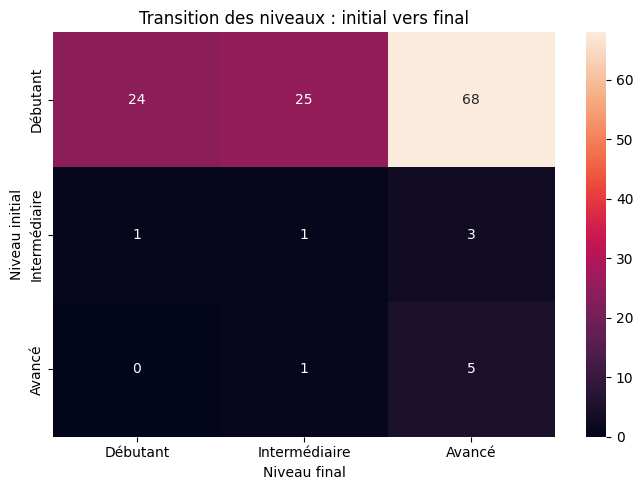

In [10]:
# ============================================================
# 3.8. Transition des niveaux initial -> final
# ============================================================

ordre_niveaux = ["Débutant", "Intermédiaire", "Avancé"]

print("===== Matrice de transition niveau initial -> niveau final =====")

matrice_transition = pd.crosstab(
    df_prediction_score["niveau_initial_global"],
    df_prediction_score["niveau_final"]
).reindex(index=ordre_niveaux, columns=ordre_niveaux, fill_value=0)

display(matrice_transition)

matrice_transition_pct = pd.crosstab(
    df_prediction_score["niveau_initial_global"],
    df_prediction_score["niveau_final"],
    normalize="index"
).reindex(index=ordre_niveaux, columns=ordre_niveaux, fill_value=0) * 100

display(matrice_transition_pct.round(2))

# Export
exporter_tableau(
    matrice_transition.reset_index(),
    "matrice_transition_niveau_initial_final.csv"
)

exporter_tableau(
    matrice_transition_pct.round(2).reset_index(),
    "matrice_transition_niveau_initial_final_pct.csv"
)

# Graphique
plt.figure(figsize=(7, 5))
sns.heatmap(matrice_transition, annot=True, fmt="d")
plt.title("Transition des niveaux : initial vers final")
plt.xlabel("Niveau final")
plt.ylabel("Niveau initial")
plt.tight_layout()
plt.savefig(FIG_DIR / "transition_niveau_initial_final.png", dpi=300)
plt.show()

# Cellule 10 — Analyse des scores initiaux par domaine

===== Scores initiaux par domaine =====


,domaine,score_moyen_sur_5,score_min,score_max,score_median,pourcentage_moyen
0,DA,1.38,0,5,1.0,27.61
1,BI,1.08,0,5,1.0,21.57
2,DS,1.08,0,5,1.0,21.51
3,IA,1.04,0,5,0.0,20.85


Exporté : outputs/03_analyse_exploratoire/scores_initiaux_par_domaine.csv


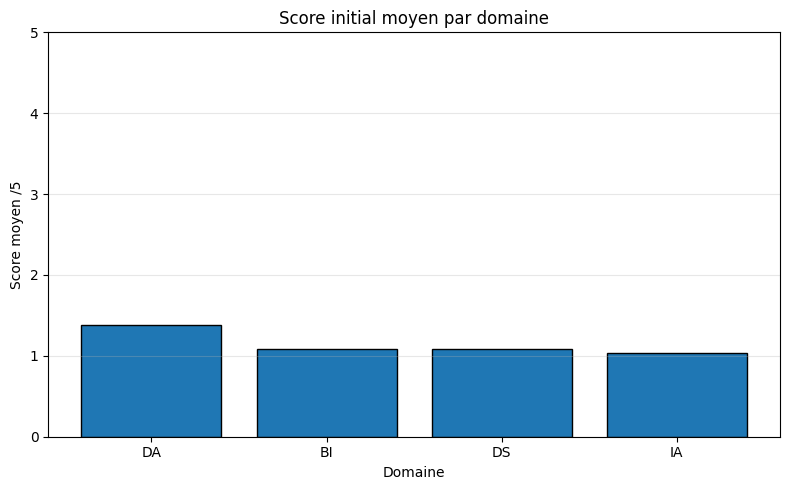

===== Répartition des niveaux initiaux par domaine =====


,domaine,niveau,effectif
0,DA,Débutant,250
1,DA,Intermédiaire,22
2,DA,Avancé,33
3,BI,Débutant,260
4,BI,Intermédiaire,23
5,BI,Avancé,22
6,DS,Débutant,264
7,DS,Intermédiaire,17
8,DS,Avancé,24
9,IA,Débutant,263


Exporté : outputs/03_analyse_exploratoire/repartition_niveaux_initiaux_par_domaine.csv


In [11]:
# ============================================================
# 3.9. Analyse des scores initiaux par domaine
# DA / BI / DS / IA
# ============================================================

domaines = ["DA", "BI", "DS", "IA"]

lignes_domaines = []

for domaine in domaines:
    lignes_domaines.append({
        "domaine": domaine,
        "score_moyen_sur_5": df_scores_initial[f"score_initial_{domaine}"].mean(),
        "score_min": df_scores_initial[f"score_initial_{domaine}"].min(),
        "score_max": df_scores_initial[f"score_initial_{domaine}"].max(),
        "score_median": df_scores_initial[f"score_initial_{domaine}"].median(),
        "pourcentage_moyen": df_scores_initial[f"score_initial_{domaine}_pct"].mean()
    })

df_scores_domaines_initial = pd.DataFrame(lignes_domaines).round(2)

print("===== Scores initiaux par domaine =====")
display(df_scores_domaines_initial)

exporter_tableau(
    df_scores_domaines_initial,
    "scores_initiaux_par_domaine.csv"
)

# Graphique score moyen par domaine
plt.figure(figsize=(8, 5))
plt.bar(
    df_scores_domaines_initial["domaine"],
    df_scores_domaines_initial["score_moyen_sur_5"],
    edgecolor="black"
)
plt.title("Score initial moyen par domaine")
plt.xlabel("Domaine")
plt.ylabel("Score moyen /5")
plt.ylim(0, 5)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "score_initial_moyen_par_domaine.png", dpi=300)
plt.show()


# Répartition des niveaux par domaine
repartition_niveaux_domaines = []

for domaine in domaines:
    repartition = (
        df_scores_initial[f"niveau_initial_{domaine}"]
        .value_counts()
        .reindex(ordre_niveaux, fill_value=0)
    )
    
    for niveau, effectif in repartition.items():
        repartition_niveaux_domaines.append({
            "domaine": domaine,
            "niveau": niveau,
            "effectif": effectif
        })

df_repartition_niveaux_domaines = pd.DataFrame(repartition_niveaux_domaines)

print("===== Répartition des niveaux initiaux par domaine =====")
display(df_repartition_niveaux_domaines)

exporter_tableau(
    df_repartition_niveaux_domaines,
    "repartition_niveaux_initiaux_par_domaine.csv"
)

Cette cellule montre dans quel domaine les apprenants sont les plus faibles au départ : DA, BI, DS ou IA.
Interprétation courte :

Score initial moyen par domaine :
DA : 1,38 /5
BI : 1,08 /5
DS : 1,08 /5
IA : 1,04 /5

Conclusion :

Les apprenants étaient faibles au départ dans tous les domaines.
Le domaine le plus faible est IA.
Le domaine le moins faible est DA.

# Cellule 11 — Analyse des niveaux finaux par parcours

===== Niveaux finaux par parcours =====


niveau_final,Débutant,Intermédiaire,Avancé
parcours_test_final,,,
DA,4,5,25
BI,11,17,32
DS,9,7,32
IA,17,10,37


niveau_final,Débutant,Intermédiaire,Avancé
parcours_test_final,,,
DA,11.76,14.71,73.53
BI,18.33,28.33,53.33
DS,18.75,14.58,66.67
IA,26.56,15.62,57.81


Exporté : outputs/03_analyse_exploratoire/niveaux_finaux_par_parcours.csv
Exporté : outputs/03_analyse_exploratoire/niveaux_finaux_par_parcours_pct.csv


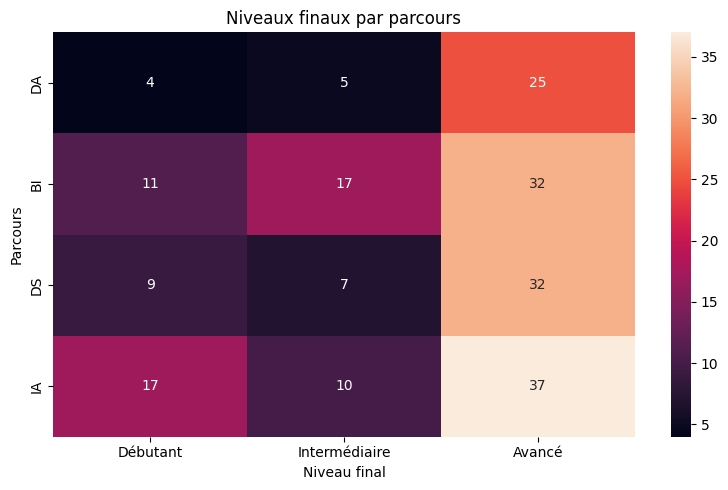

In [12]:
# ============================================================
# 3.10. Analyse des niveaux finaux par parcours
# ============================================================

ordre_parcours = ["DA", "BI", "DS", "IA"]
ordre_niveaux = ["Débutant", "Intermédiaire", "Avancé"]

print("===== Niveaux finaux par parcours =====")

matrice_niveaux_final_parcours = pd.crosstab(
    df_scores_finaux["parcours_test_final"],
    df_scores_finaux["niveau_final"]
).reindex(index=ordre_parcours, columns=ordre_niveaux, fill_value=0)

display(matrice_niveaux_final_parcours)

matrice_niveaux_final_parcours_pct = pd.crosstab(
    df_scores_finaux["parcours_test_final"],
    df_scores_finaux["niveau_final"],
    normalize="index"
).reindex(index=ordre_parcours, columns=ordre_niveaux, fill_value=0) * 100

display(matrice_niveaux_final_parcours_pct.round(2))

exporter_tableau(
    matrice_niveaux_final_parcours.reset_index(),
    "niveaux_finaux_par_parcours.csv"
)

exporter_tableau(
    matrice_niveaux_final_parcours_pct.round(2).reset_index(),
    "niveaux_finaux_par_parcours_pct.csv"
)

plt.figure(figsize=(8, 5))
sns.heatmap(matrice_niveaux_final_parcours, annot=True, fmt="d")
plt.title("Niveaux finaux par parcours")
plt.xlabel("Niveau final")
plt.ylabel("Parcours")
plt.tight_layout()
plt.savefig(FIG_DIR / "niveaux_finaux_par_parcours.png", dpi=300)
plt.show()

Interprétation courte :

DA : 73,53 % Avancé → meilleur taux final
DS : 66,67 % Avancé
IA : 57,81 % Avancé
BI : 53,33 % Avancé

Conclusion :

Tous les parcours produisent une majorité d’apprenants Avancés.
Le parcours DA est le plus performant en niveau final.
Le parcours IA garde le plus d’apprenants Débutants

# Cellule 12 — Analyse des profils par niveau final

In [13]:
# ============================================================
# 3.11. Analyse des profils des apprenants par niveau final
# ============================================================

colonnes_profil = [
    "ins_Genre",
    "ins_Filière",
    "ins_Niveau d'étude",
    "ins_Statut actuel",
    "ins_Niveau informatique",
    "ins_Niveau Excel",
    "ins_Niveau Power BI",
    "ins_Niveau Python",
    "ins_Niveau IA"
]

colonnes_profil_existantes = [
    col for col in colonnes_profil
    if col in df_prediction_score.columns
]

print("Colonnes de profil disponibles :")
print(colonnes_profil_existantes)

for col in colonnes_profil_existantes:
    print(f"\n===== Profil : {col} / niveau final =====")
    
    tableau = pd.crosstab(
        df_prediction_score[col],
        df_prediction_score["niveau_final"]
    ).reindex(columns=ordre_niveaux, fill_value=0)
    
    display(tableau)
    
    tableau_pct = pd.crosstab(
        df_prediction_score[col],
        df_prediction_score["niveau_final"],
        normalize="index"
    ).reindex(columns=ordre_niveaux, fill_value=0) * 100
    
    display(tableau_pct.round(2))
    
    exporter_tableau(
        tableau.reset_index(),
        f"profil_{col.replace('ins_', '').replace(' ', '_')}_niveau_final.csv"
    )

Colonnes de profil disponibles :
['ins_Genre', 'ins_Filière', "ins_Niveau d'étude", 'ins_Statut actuel', 'ins_Niveau informatique', 'ins_Niveau Excel', 'ins_Niveau Power BI', 'ins_Niveau Python', 'ins_Niveau IA']

===== Profil : ins_Genre / niveau final =====


niveau_final,Débutant,Intermédiaire,Avancé
ins_Genre,,,
Feminin,6,15,22
Masculin,19,12,54


niveau_final,Débutant,Intermédiaire,Avancé
ins_Genre,,,
Feminin,13.95,34.88,51.16
Masculin,22.35,14.12,63.53


Exporté : outputs/03_analyse_exploratoire/profil_Genre_niveau_final.csv

===== Profil : ins_Filière / niveau final =====


niveau_final,Débutant,Intermédiaire,Avancé
ins_Filière,,,
Autre,3,5,17
Communication / Journalisme,1,0,0
Droit / Sciences politiques,0,1,1
"EGS - Economie, Gestion & Sociologie",12,12,31
IST - Informatique & Sciences des Technologies,1,2,8
Informatique / Genie logiciel,0,0,5
Lettres & Sciences humaines,3,2,6
Medecine / Sciences de la sante,1,2,3
Polytechnique / Genie civil / Genie industriel,3,2,5


...

niveau_final,Débutant,Intermédiaire,Avancé
ins_Niveau Python,,,
Aucun,23.33,21.67,55.00
Avance,0.00,0.00,100.00
Debutant,19.15,25.53,55.32
Intermediaire,10.00,10.00,80.00


Exporté : outputs/03_analyse_exploratoire/profil_Niveau_Python_niveau_final.csv

===== Profil : ins_Niveau IA / niveau final =====


niveau_final,Débutant,Intermédiaire,Avancé
ins_Niveau IA,,,
Aucun,4,3,9
Avance,0,0,3
Debutant,15,15,45
Intermediaire,6,9,19


niveau_final,Débutant,Intermédiaire,Avancé
ins_Niveau IA,,,
Aucun,25.00,18.75,56.25
Avance,0.00,0.00,100.00
Debutant,20.00,20.00,60.00
Intermediaire,17.65,26.47,55.88


Exporté : outputs/03_analyse_exploratoire/profil_Niveau_IA_niveau_final.csv


Interprétation courte :

La majorité des profils atteignent le niveau Avancé final.
Mais attention : certaines catégories ont très peu d’apprenants, donc il ne faut pas trop interpréter les 100 %.

Constats utiles :

- Masculin : 63,53 % Avancé
- Féminin : 51,16 % Avancé
- Niveau informatique Avancé : 100 % Avancé, mais effectif faible
- Informatique / Génie logiciel : 100 % Avancé, mais effectif faible

Conclusion :

Les profils semblent influencer les résultats, mais il faudra confirmer avec le ML.

# Cellule 13 — Corrélation entre scores initiaux, score final et progression

Cette cellule va montrer quelles variables initiales sont liées au score final et à la progression

===== Matrice de corrélation =====


,score_initial_DA,score_initial_BI,score_initial_DS,score_initial_IA,score_initial_total,score_initial_pourcentage,unknown_total_initial,score_final_total,score_final_pourcentage,progression_absolue
score_initial_DA,1.000,0.587,0.479,0.510,0.802,0.802,-0.440,0.138,0.138,-0.491
score_initial_BI,0.587,1.000,0.480,0.561,0.808,0.808,-0.612,0.185,0.185,-0.458
score_initial_DS,0.479,0.480,1.000,0.577,0.794,0.794,-0.469,0.161,0.161,-0.468
score_initial_IA,0.510,0.561,0.577,1.000,0.818,0.818,-0.543,0.127,0.127,-0.514
score_initial_total,0.802,0.808,0.794,0.818,1.000,1.000,-0.638,0.189,0.189,-0.599
score_initial_pourcentage,0.802,0.808,0.794,0.818,1.000,1.000,-0.638,0.189,0.189,-0.599
unknown_total_initial,-0.440,-0.612,-0.469,-0.543,-0.638,-0.638,1.000,-0.018,-0.018,0.466
score_final_total,0.138,0.185,0.161,0.127,0.189,0.189,-0.018,1.000,1.000,0.672
score_final_pourcentage,0.138,0.185,0.161,0.127,0.189,0.189,-0.018,1.000,1.000,0.672
progression_absolue,-0.491,-0.458,-0.468,-0.514,-0.599,-0.599,0.466,0.672,0.672,1.000


Exporté : outputs/03_analyse_exploratoire/matrice_correlation_scores_progression.csv


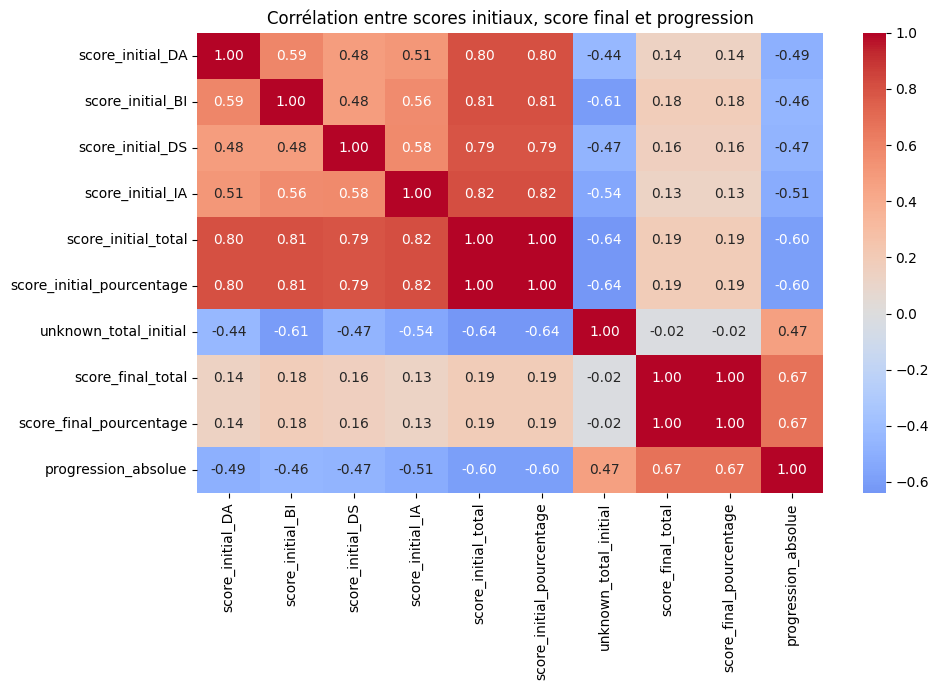

In [14]:
# ============================================================
# 3.12. Corrélation entre scores initiaux, score final et progression
# ============================================================

colonnes_correlation = [
    "score_initial_DA",
    "score_initial_BI",
    "score_initial_DS",
    "score_initial_IA",
    "score_initial_total",
    "score_initial_pourcentage",
    "unknown_total_initial",
    "score_final_total",
    "score_final_pourcentage",
    "progression_absolue"
]

colonnes_correlation_existantes = [
    col for col in colonnes_correlation
    if col in df_prediction_score.columns
]

df_correlation = df_prediction_score[colonnes_correlation_existantes].corr().round(3)

print("===== Matrice de corrélation =====")
display(df_correlation)

exporter_tableau(
    df_correlation.reset_index(),
    "matrice_correlation_scores_progression.csv"
)

plt.figure(figsize=(10, 7))
sns.heatmap(df_correlation, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Corrélation entre scores initiaux, score final et progression")
plt.tight_layout()
plt.savefig(FIG_DIR / "correlation_scores_progression.png", dpi=300)
plt.show()

Oui, **Cellule 13 validée**.

Interprétation courte :

```text
1. Score initial ↔ score final : corrélation faible
```

Le score initial prédit peu le score final directement.

```text
score_initial_total ↔ score_final_total = 0.19
```

Donc un apprenant faible au départ peut quand même devenir fort à la fin.

```text
2. Score initial ↔ progression : corrélation négative forte
```

```text
score_initial_total ↔ progression = -0.60
```

Cela veut dire : plus l’apprenant était faible au départ, plus il avait une grande marge de progression.

```text
3. Score final ↔ progression : corrélation positive
```

```text
score_final_total ↔ progression = 0.67
```

Les meilleurs scores finaux sont associés à une forte progression.

```text
4. unknown_total_initial
```

```text
unknown_total_initial ↔ score_initial = -0.64
unknown_total_initial ↔ score_final = -0.02
```

Beaucoup de “Je ne sais pas” au départ baisse le score initial, mais ne bloque pas forcément le score final.

Conclusion :

```text
Le niveau initial est faible, mais la progression finale est forte.
Le score initial seul n’explique pas totalement la réussite finale.
```

# Cellule 14 — Identifier les apprenants en progression, stabilité et régression

In [15]:
# ============================================================
# 3.13. Identification des apprenants en progression / stable / régression
# ============================================================

colonnes_resume_apprenants = [
    "IDENTIFICATION",
    "score_initial_total",
    "score_initial_pourcentage",
    "niveau_initial_global",
    "parcours_test_final",
    "score_final_total",
    "score_final_pourcentage",
    "niveau_final",
    "progression_absolue",
    "statut_progression"
]

df_progression_apprenants = df_prediction_score[colonnes_resume_apprenants].copy()

print("===== Répartition des statuts de progression =====")
display(df_progression_apprenants["statut_progression"].value_counts())

print("\n===== Apprenants en progression =====")
display(
    df_progression_apprenants[
        df_progression_apprenants["statut_progression"] == "Progression"
    ].head(20)
)

print("\n===== Apprenants stables =====")
display(
    df_progression_apprenants[
        df_progression_apprenants["statut_progression"] == "Stable"
    ]
)

print("\n===== Apprenants en régression =====")
display(
    df_progression_apprenants[
        df_progression_apprenants["statut_progression"] == "Régression"
    ]
)

# Export
exporter_tableau(
    df_progression_apprenants,
    "progression_apprenants_detail.csv"
)

exporter_tableau(
    df_progression_apprenants[
        df_progression_apprenants["statut_progression"] == "Régression"
    ],
    "apprenants_en_regression.csv"
)

===== Répartition des statuts de progression =====


statut_progression
Progression    118
Stable           6
Régression       4
Name: count, dtype: int64


===== Apprenants en progression =====


,IDENTIFICATION,score_initial_total,score_initial_pourcentage,niveau_initial_global,parcours_test_final,score_final_total,score_final_pourcentage,niveau_final,progression_absolue,statut_progression
0,DIEG2026-003,0,0.0,Débutant,IA,14,93.333333,Avancé,93.333333,Progression
1,DIEG2026-007,8,40.0,Débutant,IA,12,80.000000,Avancé,40.000000,Progression
2,DIEG2026-008,4,20.0,Débutant,BI,15,100.000000,Avancé,80.000000,Progression
3,DIEG2026-009,7,35.0,Débutant,IA,14,93.333333,Avancé,58.333333,Progression
4,DIEG2026-012,2,10.0,Débutant,IA,8,53.333333,Intermédiaire,43.333333,Progression
5,DIEG2026-025,4,20.0,Débutant,DS,13,86.666667,Avancé,66.666667,Progression
6,DIEG2026-026,1,5.0,Débutant,BI,9,60.000000,Intermédiaire,55.000000,Progression
7,DIEG2026-027,1,5.0,Débutant,BI,9,60.000000,Intermédiaire,55.000000,Progression
8,DIEG2026-028,2,10.0,Débutant,BI,12,80.000000,Avancé,70.000000,Progression
9,DIEG2026-029,1,5.0,Débutant,IA,11,73.333333,Avancé,68.333333,Progression



===== Apprenants stables =====


,IDENTIFICATION,score_initial_total,score_initial_pourcentage,niveau_initial_global,parcours_test_final,score_final_total,score_final_pourcentage,niveau_final,progression_absolue,statut_progression
30,DIEG2026-057,9,45.0,Débutant,BI,6,40.000000,Débutant,-5.000000,Stable
57,DIEG2026-148,20,100.0,Avancé,DS,15,100.000000,Avancé,0.000000,Stable
84,DIEG2026-307,20,100.0,Avancé,DS,15,100.000000,Avancé,0.000000,Stable
85,DIEG2026-310,19,95.0,Avancé,DS,15,100.000000,Avancé,5.000000,Stable
111,DIEG2026-431,19,95.0,Avancé,BI,14,93.333333,Avancé,-1.666667,Stable
117,DIEG2026-445,6,30.0,Débutant,IA,5,33.333333,Débutant,3.333333,Stable



===== Apprenants en régression =====


,IDENTIFICATION,score_initial_total,score_initial_pourcentage,niveau_initial_global,parcours_test_final,score_final_total,score_final_pourcentage,niveau_final,progression_absolue,statut_progression
31,DIEG2026-061,20,100.0,Avancé,DS,8,53.333333,Intermédiaire,-46.666667,Régression
35,DIEG2026-073,10,50.0,Intermédiaire,DS,5,33.333333,Débutant,-16.666667,Régression
73,DIEG2026-250,5,25.0,Débutant,IA,2,13.333333,Débutant,-11.666667,Régression
105,DIEG2026-410,5,25.0,Débutant,IA,1,6.666667,Débutant,-18.333333,Régression


Exporté : outputs/03_analyse_exploratoire/progression_apprenants_detail.csv
Exporté : outputs/03_analyse_exploratoire/apprenants_en_regression.csv


Résultat important :

Progression : 118 apprenants
Stable : 6 apprenants
Régression : 4 apprenants

Les 4 apprenants en régression sont à vérifier :

DIEG2026-061
DIEG2026-073
DIEG2026-250
DIEG2026-410

# Cellule 15 — Rapport automatique de l’Étape 3

In [16]:
# ============================================================
# 3.14. Rapport automatique de l'Étape 3 — VERSION CORRIGÉE
# ============================================================

import json
from datetime import datetime

def convertir_objet_json(obj):
    if isinstance(obj, dict):
        return {str(k): convertir_objet_json(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [convertir_objet_json(v) for v in obj]
    elif isinstance(obj, tuple):
        return list(obj)
    elif hasattr(obj, "item"):
        return obj.item()
    else:
        return obj


rapport_step3 = {
    "etape": "Étape 3 — Analyse exploratoire des scores et profils des apprenants",
    "date_generation": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),

    "scores_generaux": {
        "score_initial_moyen_sur_20": df_scores_initial["score_initial_total"].mean(),
        "score_intermediaire_moyen_sur_15": df_scores_intermediaires["score_intermediaire_total"].mean(),
        "score_final_moyen_sur_15": df_scores_finaux["score_final_total"].mean()
    },

    "niveaux": {
        "niveaux_initiaux": df_scores_initial["niveau_initial_global"].value_counts().to_dict(),
        "niveaux_intermediaires": df_scores_intermediaires["niveau_intermediaire"].value_counts().to_dict(),
        "niveaux_finaux": df_scores_finaux["niveau_final"].value_counts().to_dict()
    },

    "progression": {
        "statuts_progression": df_prediction_score["statut_progression"].value_counts().to_dict(),
        "progression_moyenne": df_prediction_score["progression_absolue"].mean(),
        "progression_mediane": df_prediction_score["progression_absolue"].median(),
        "progression_min": df_prediction_score["progression_absolue"].min(),
        "progression_max": df_prediction_score["progression_absolue"].max()
    },

    "progression_par_parcours": scores_parcours.to_dict(orient="records"),
    "scores_initiaux_par_domaine": df_scores_domaines_initial.to_dict(orient="records"),

    "apprenants_en_regression": df_progression_apprenants[
        df_progression_apprenants["statut_progression"] == "Régression"
    ]["IDENTIFICATION"].tolist(),

    "conclusion": (
        "L'analyse exploratoire montre un niveau initial globalement faible, "
        "mais une forte progression vers les tests intermédiaires et finaux. "
        "La majorité des apprenants atteint le niveau Avancé au test final."
    ),

    "prochaine_etape": "Étape 4 — Recommandation initiale de parcours"
}

rapport_step3 = convertir_objet_json(rapport_step3)


# Export JSON
PATH_RAPPORT_STEP3_JSON = OUTPUT_DIR / "rapport_step3_analyse_exploratoire.json"

with open(PATH_RAPPORT_STEP3_JSON, "w", encoding="utf-8") as f:
    json.dump(rapport_step3, f, ensure_ascii=False, indent=4)


# Tableau Markdown manuel pour éviter l'erreur tabulate
progression_counts = df_prediction_score["statut_progression"].value_counts()

lignes_progression_md = ""
for statut, effectif in progression_counts.items():
    lignes_progression_md += f"| {statut} | {effectif} |\n"


# Export Markdown
rapport_markdown = f"""# Rapport automatique — Étape 3

## Étape
Étape 3 — Analyse exploratoire des scores et profils des apprenants

## Date de génération
{rapport_step3["date_generation"]}

## 1. Scores moyens

| Score | Moyenne |
|---|---:|
| Score initial /20 | {df_scores_initial["score_initial_total"].mean():.2f} |
| Score intermédiaire /15 | {df_scores_intermediaires["score_intermediaire_total"].mean():.2f} |
| Score final /15 | {df_scores_finaux["score_final_total"].mean():.2f} |

## 2. Progression initiale vers finale

| Statut | Effectif |
|---|---:|
{lignes_progression_md}

## 3. Conclusion

L’analyse exploratoire montre que les apprenants avaient un niveau initial faible, mais qu’une majorité progresse fortement après la formation.

## 4. Prochaine étape

Étape 4 — Recommandation initiale de parcours.
"""

PATH_RAPPORT_STEP3_MD = OUTPUT_DIR / "rapport_step3_analyse_exploratoire.md"

with open(PATH_RAPPORT_STEP3_MD, "w", encoding="utf-8") as f:
    f.write(rapport_markdown)


print("Rapport Étape 3 généré.")
print("JSON :", PATH_RAPPORT_STEP3_JSON)
print("Markdown :", PATH_RAPPORT_STEP3_MD)

print("\nÉtape 3 validée.")
print("Prochaine étape : Étape 4 — Recommandation initiale de parcours")

rapport_step3

Rapport Étape 3 généré.
JSON : outputs/03_analyse_exploratoire/rapport_step3_analyse_exploratoire.json
Markdown : outputs/03_analyse_exploratoire/rapport_step3_analyse_exploratoire.md

Étape 3 validée.
Prochaine étape : Étape 4 — Recommandation initiale de parcours


{'etape': 'Étape 3 — Analyse exploratoire des scores et profils des apprenants',
 'date_generation': '2026-09-18 11:35:30',
 'scores_generaux': {'score_initial_moyen_sur_20': 4.577049180327869,
  'score_intermediaire_moyen_sur_15': 10.811224489795919,
  'score_final_moyen_sur_15': 11.004854368932039},
 'niveaux': {'niveaux_initiaux': {'Débutant': 268,
   'Intermédiaire': 22,
   'Avancé': 15},
  'niveaux_intermediaires': {'Avancé': 108,
   'Intermédiaire': 54,
   'Débutant': 34},
  'niveaux_finaux': {'Avancé': 126, 'Débutant': 41, 'Intermédiaire': 39}},
 'progression': {'statuts_progression': {'Progression': 118,
   'Stable': 6,
   'Régression': 4},
  'progression_moyenne': 51.48437499999999,
  'progression_mediane': 55.0,
  'progression_min': -46.66666666666666,
  'progression_max': 100.0},
 'progression_par_parcours': [{'parcours_test_final': 'BI',
   'nb_apprenants': 42,
   'score_initial_moyen': 15.6,
   'score_final_moyen': 69.68,
   'progression_moyenne': 54.09},
  {'parcours_test

Oui, **Cellule 15 Terminée**.

Donc :

```text
Étape 3 — Analyse exploratoire des scores et profils : TERMINÉE
```

Fichiers générés :

```text
outputs/03_analyse_exploratoire/rapport_step3_analyse_exploratoire.json
outputs/03_analyse_exploratoire/rapport_step3_analyse_exploratoire.md
```

Résultats clés :

```text
Score initial moyen : 4,58 /20
Score intermédiaire moyen : 10,81 /15
Score final moyen : 11,00 /15
Progression : 118 apprenants
Stable : 6 apprenants
Régression : 4 apprenants
```

Conclusion :

```text
Les apprenants partent majoritairement d’un niveau faible, mais progressent fortement après la formation.
```

Prochaine étape :

```text
Étape 4 — Recommandation initiale de parcours
```

Objectif : recommander automatiquement un parcours adapté **DA / BI / DS / IA** à partir du profil et du test initial.
